# EcoSort AI Classifier

## Data Collection and Dataset preparation
Firstly, we have to curate a dataset from different datasets and tailor it to our needs.
We are going to look at and download these datasets:
1. **Recyclable**: TrashNet (Gary Thung & Ming-Sheng Yang) and the TACO Dataset (`Trash Annotations in Context`). Target items: plastic bottles, aluminium beverage cans, cardboard boxes, clean glass jars.
2. **Wet (Organic)**: Source from the Waste Classification Dataset (Kaggle - `Techsash`) under category `O` (Organic) or the Food Waste Image Dataset. Target items: vegetable peels, fruit rinds, leftover food, tea bags, fallen leaves.
3. **E-waste**: Source from the Electronic Waste Classification Dataset (Kaggle) or E-Waste Image Dataset. Target items: printed circuit boards (PCBs), discarded smartphones, damaged cables/chargers, computer mice, keyboards, batteries.
4. **Dry (Non-recyclable / Residual)**: Source from the trash category of TrashNet and general residual waste subsets. Target items: soiled tissues, plastic cutlery, chip/snack multi-layer laminate wrappers, polystyrene/Styrofoam packaging.

**Note:** Our dataset is highly **_skewed_**.
1. `ewaste` has 3,002 images
2. `dry` has 702 images
3. wet` has 17,350 images
4. `recyclable` has 16,279 images
Upon considering these details, we must focus on precision/recall and F1 score, and we are not going to blindly follow the Accuracy metric.

### Import required libraries

In [1]:
# import torch and torchvision
import torch
import torchvision
print(torch.__version__, torchvision.__version__)

2.12.1+cu130 0.27.1+cu130


In [2]:
# continue with regular imports
from torch import nn
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchinfo import summary
import data_setup, engine

In [3]:
# Set up device-agnostic code
device ='cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

### Get Data
Get the  dry, ewaste, recyclable, wet waste data to train our models.

In [4]:
from pathlib import Path
data_path = Path('data/')
data_path

WindowsPath('data')

In [5]:
# Set up train, cross val and test dir
train_dir = data_path / 'train'
val_dir = data_path / 'val'
test_dir = data_path / 'test'
train_dir, val_dir, test_dir

(WindowsPath('data/train'), WindowsPath('data/val'), WindowsPath('data/test'))

### Transform the data
Using `torchvision.transforms.v2` we shall transform the dataset and prepare dataloaders for our first model: the baseline model.

In [6]:
import torchvision.transforms.v2 as transforms
from torchvision import datasets
# Create a simple transform for our baseline model
data_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
])
# Use the `create_dataloaders()` function from data_setup.py file
train_dataloader, val_dataloader, class_names = data_setup.create_dataloaders(train_dir,
                                                                               val_dir,
                                                                               data_transform,
                                                                               batch_size=64,
                                                                               num_workers=4)

In [7]:
train_dataloader, val_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x1f843c1c440>,
 ['dry', 'ewaste', 'recyclable', 'wet'])

In [8]:
# Test the dataloaders
next(iter(train_dataloader))

[tensor([[[[0.7059, 0.8157, 0.7059,  ..., 0.8588, 0.7529, 0.7137],
           [0.6510, 0.6667, 0.4275,  ..., 0.7804, 0.7686, 0.7451],
           [0.2745, 0.2667, 0.2431,  ..., 0.7451, 0.7490, 0.7765],
           ...,
           [0.8706, 0.8549, 0.8784,  ..., 0.9490, 0.9686, 0.9176],
           [0.9569, 0.9333, 0.7804,  ..., 0.9059, 0.9725, 0.8706],
           [0.9922, 0.9451, 0.7529,  ..., 0.8314, 0.9608, 0.8275]],
 
          [[0.5922, 0.6980, 0.5843,  ..., 0.7373, 0.6314, 0.5882],
           [0.5451, 0.5569, 0.3176,  ..., 0.6510, 0.6353, 0.6118],
           [0.1922, 0.1843, 0.1569,  ..., 0.6196, 0.6157, 0.6392],
           ...,
           [0.7373, 0.7255, 0.7647,  ..., 0.8549, 0.8784, 0.8235],
           [0.8196, 0.7961, 0.6549,  ..., 0.8118, 0.8745, 0.7608],
           [0.8588, 0.8157, 0.6196,  ..., 0.7333, 0.8588, 0.7098]],
 
          [[0.4745, 0.5843, 0.4863,  ..., 0.5922, 0.4902, 0.4510],
           [0.4275, 0.4471, 0.2196,  ..., 0.5059, 0.4941, 0.4667],
           [0.0784, 0.07

## Making Classifiers to classify the data
We are going to make three models: a baseline, feature-extracted pretrained CNN model, and a pretrained transformer model.
### 1. Baseline Model
The baseline model is a simple CNN model that we shall train to classify the data.
For the baseline model we are going to use the ResNet-18 architecture. Source:  [ResNet-18 Architecture](https://www.geeksforgeeks.org/deep-learning/resnet18-from-scratch-using-pytorch/)

In [9]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += self.shortcut(x)
        out = self.relu(out)
        return out

In [10]:
class ResNet18(nn.Module):
    def __init__(self, num_classes=len(class_names)):
        super().__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.layer1 = self._make_layer(BasicBlock, 64, 2, stride=1)
        self.layer2 = self._make_layer(BasicBlock, 128, 2, stride=2)
        self.layer3 = self._make_layer(BasicBlock, 256, 2, stride=2)
        self.layer4 = self._make_layer(BasicBlock, 512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

model_0 = ResNet18().to(device)
print(model_0)

ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2)

In [11]:
# 1. Get a batch of images and labels from the DataLoader
img_batch, label_batch = next(iter(train_dataloader))

# 2. Get a single image from the batch and unsqueeze the image so its shape fits the model
img_single, label_single = img_batch[0].unsqueeze(dim=0), label_batch[0]
print(f"Single image shape: {img_single.shape}\n")

# 3. Perform a forward pass on a single image
model_0.eval()
with torch.inference_mode():
    pred = model_0(img_single.to(device))

# 4. Print out what's happening and convert model logits -> pred probs -> pred label
print(f"Output logits:\n{pred}\n")
print(f"Output prediction probabilities:\n{torch.softmax(pred, dim=1)}\n")
print(f"Output prediction label:\n{torch.argmax(torch.softmax(pred, dim=1), dim=1)}\n")
print(f"Actual label:\n{label_single}")

Single image shape: torch.Size([1, 3, 64, 64])

Output logits:
tensor([[-0.0174, -0.0149,  0.0076, -0.0086]], device='cuda:0')

Output prediction probabilities:
tensor([[0.2477, 0.2483, 0.2540, 0.2499]], device='cuda:0')

Output prediction label:
tensor([2], device='cuda:0')

Actual label:
2


### Training the BaseLine
Let us train the model above using training scripts.

In [13]:
from engine import train
# Set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
NUM_EPOCHS = 5

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_0
model_0_results = train(model=model_0,
                        train_dataloader=train_dataloader,
                        val_dataloader=val_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS,
                        device=device)

# End the timer and print out how long it took
end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.6687 | train_acc: 0.7425 | train_f1: 0.4563 | val_loss: 0.5806 | val_acc: 0.7792 | val_f1: 0.5147
Epoch: 2 | train_loss: 0.5595 | train_acc: 0.7844 | train_f1: 0.5128 | val_loss: 0.5424 | val_acc: 0.7914 | val_f1: 0.5253
Epoch: 3 | train_loss: 0.5246 | train_acc: 0.8014 | train_f1: 0.5390 | val_loss: 0.5259 | val_acc: 0.7999 | val_f1: 0.5369
Epoch: 4 | train_loss: 0.5007 | train_acc: 0.8095 | train_f1: 0.5457 | val_loss: 0.5607 | val_acc: 0.7859 | val_f1: 0.5324
Epoch: 5 | train_loss: 0.4819 | train_acc: 0.8162 | train_f1: 0.5577 | val_loss: 0.5340 | val_acc: 0.7876 | val_f1: 0.5136
[INFO] Total training time: 361.045 seconds


In [14]:
from utils import save_model
save_model(model_0,
           target_dir='models',
           model_name='01_baseline_model.pt')

[INFO] Saving model to: models\01_baseline_model.pt


In [15]:
model_0_results

{'train_loss': [0.6687105979821454,
  0.5595117172266406,
  0.5245821804333106,
  0.5007122842533015,
  0.48192361405451006],
 'train_acc': [np.float64(0.7425415378966372),
  np.float64(0.7844313209510113),
  np.float64(0.8013830666136287),
  np.float64(0.809522352437196),
  np.float64(0.8162234937731404)],
 'train_precision': [0.49941029757149463,
  0.5490351931460105,
  0.5677219464207277,
  0.5721723786218911,
  0.6788799557960178],
 'train_recall': [0.44642347466542887,
  0.49826019563063934,
  0.5246013577363365,
  0.531993017277047,
  0.5440262116322814],
 'train_f1': [0.4562839476783715,
  0.5128421361240248,
  0.5389585468539465,
  0.5457051565183801,
  0.5576992068733613],
 'val_loss': [0.5805824932630186,
  0.542380713313431,
  0.5259162958155011,
  0.5606708320510851,
  0.5340102577049818],
 'val_acc': [np.float64(0.7792168060371202),
  np.float64(0.7913522333265348),
  np.float64(0.7999184172955334),
  np.float64(0.785947379155619),
  np.float64(0.787579033244952)],
 'val_p

**Note:** We are after the F1 score, not the blind accuracy. So, our baseline may have reached validation accuracy of ~80%, F1 score is only ~51.36%. So our goal is to make this better.

### Feature Extracting a pretrained CNN: `EfficientNetV2`
We are now going to train a transfer learning model: EfficientNetV2 (S model) based architecture. Source: [EfficientNetV2 Model Paper](https://arxiv.org/abs/2104.00298). One of the main features of EfficientNet is that it uses very low MACs as compared to other models, making it very suitable and ideal for mobile device deployment. In fact, while deciding among various models, I particularly chose EfficientNet especially the V2 for this project as it requires very few MACs for faster mobile inference. However, since EfficientNet uses Squeeze and Excitation optimization on DepthSeparable Convolution Layers (MB Blocks) to drastically reduce the number of parameters, it is not the fastest model we have to date. But for our practice, however, we must keep in mind the hardware constraints in mobile device deployment and the problem we aim to solve through this project.

In [12]:
# Creating a pretrained model
weights = torchvision.models.EfficientNet_V2_S_Weights.DEFAULT # ".DEFAULT" = best available weights
model_1 = torchvision.models.efficientnet_v2_s(weights=weights).to(device)
model_1

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, bias=T

In [13]:
# Get the transforms used to train our pretrained model
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[384]
    resize_size=[384]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [14]:
model_1.features    # these are the feature layers which we are going to freeze to preserve the weights

Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): SiLU(inplace=True)
  )
  (1): Sequential(
    (0): FusedMBConv(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): SiLU(inplace=True)
        )
      )
      (stochastic_depth): StochasticDepth(p=0.0, mode=row)
    )
    (1): FusedMBConv(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): SiLU(inplace=True)
     

In [15]:
model_1.avgpool

AdaptiveAvgPool2d(output_size=1)

In [16]:
model_1.classifier  # Final layers used to classify the images

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

In [17]:
# Create dataloaders for training the model
train_dataloader, val_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                              test_dir=val_dir,
                                                                              transform=auto_transforms,
                                                                              batch_size=32,
                                                                              num_workers=0)
train_dataloader, val_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x1f84402e710>,
 ['dry', 'ewaste', 'recyclable', 'wet'])

#### Getting a summary with `torchinfo.summary()`
Use `torchinfo.summary()` to get a summary of the model.

In [18]:
# Print with torchinfo
from torchinfo import summary
summary(model=model_1,
        input_size=(1, 3, 224, 224),    # an example of [batch size, color_channels, height, width]
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 1000]            --                   True
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   True
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 24, 112, 112]    --                   True
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 24, 112, 112]    648                  True
│    │    └─BatchNorm2d (1)                                  [1, 24, 112, 112]    [1, 24, 112, 112]    48                   True
│    │    └─SiLU (2)                                         [1, 24, 112, 112]    [1, 24, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 24, 112, 112]    [1, 24, 112,

#### Freezing the base model and changing the output layer to suit our needs
With a feature extractor model, typically we will "freeze" the base layers of a pretrained/foundation model and then update the output layers to suit our own problem.

In [19]:
# Freeze all the base layers in EffNetV2M
for param in model_1.features.parameters():
    param.requires_grad = False # pyTorch will no longer track the gradients

In [20]:
# Update the classifier head to suit our problems
from torch import nn
model_1.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1280, # feature vector coming in
              out_features=len(class_names)).to(device))    # how many classes do we have?
model_1.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=4, bias=True)
)

In [21]:
# Print with torchinfo
from torchinfo import summary
summary(model=model_1,
        input_size=(1, 3, 224, 224),    # an example of [batch size, color_channels, height, width]
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 4]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 24, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 24, 112, 112]    (648)                False
│    │    └─BatchNorm2d (1)                                  [1, 24, 112, 112]    [1, 24, 112, 112]    (48)                 False
│    │    └─SiLU (2)                                         [1, 24, 112, 112]    [1, 24, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 24, 112, 112]    [1, 2

#### Train the model
Let us now train the model, leveraging the functions I had written earlier.

In [22]:
# Define the loss function
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_1.parameters(),
                             lr=0.01)

In [26]:
from timeit import default_timer as timer
start_time = timer()
# Set up training and test save the results
results = engine.train(model=model_1,
                       train_dataloader=train_dataloader,
                       val_dataloader=val_dataloader,
                       loss_fn=loss_fn,
                       optimizer=optimizer,
                       epochs=5,
                       device=torch.device(device))
# End the timer
end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.4118 | train_acc: 0.8871 | train_f1: 0.7549 | val_loss: 0.2703 | val_acc: 0.9146 | val_f1: 0.7976
Epoch: 2 | train_loss: 0.4107 | train_acc: 0.8876 | train_f1: 0.7590 | val_loss: 0.2568 | val_acc: 0.9225 | val_f1: 0.8347
Epoch: 3 | train_loss: 0.4150 | train_acc: 0.8882 | train_f1: 0.7531 | val_loss: 0.2607 | val_acc: 0.9194 | val_f1: 0.8140
Epoch: 4 | train_loss: 0.4157 | train_acc: 0.8868 | train_f1: 0.7602 | val_loss: 0.2801 | val_acc: 0.9107 | val_f1: 0.8031
Epoch: 5 | train_loss: 0.4220 | train_acc: 0.8878 | train_f1: 0.7563 | val_loss: 0.2493 | val_acc: 0.9212 | val_f1: 0.8317
[INFO] Total training time: 1708.199 seconds


In [27]:
from utils import save_model
save_model(model_0,
           target_dir='models',
           model_name='02_pretrained_CNN_model.pt')

[INFO] Saving model to: models\02_pretrained_CNN_model.pt


In [28]:
results

{'train_loss': [0.4117903231685059,
  0.4106887036847013,
  0.41499477988081657,
  0.41569685492092295,
  0.42202768132588125],
 'train_acc': [np.float64(0.8870597594932835),
  np.float64(0.8876105382332242),
  np.float64(0.8881613169731648),
  np.float64(0.8868455677610845),
  np.float64(0.8878247299654234)],
 'train_precision': [0.759318859298945,
  0.7643476813328697,
  0.7559389446784951,
  0.7645186314845963,
  0.7610493972310113],
 'train_recall': [0.7511444079818308,
  0.7546699109793616,
  0.75072363954792,
  0.7565326174050561,
  0.7520984285992055],
 'train_f1': [0.7548862902278601,
  0.7590476602796239,
  0.7531241220962678,
  0.7601686409146252,
  0.756257612283435],
 'val_loss': [0.2702820695516618,
  0.25677228993401563,
  0.2607273121685979,
  0.2801030533262077,
  0.24932786417541156],
 'val_acc': [np.float64(0.9146440954517642),
  np.float64(0.9224964307566795),
  np.float64(0.9194370793391801),
  np.float64(0.9106669386090149),
  np.float64(0.9211707118090965)],
 'val

In [53]:
# Plot loss curves of a model
import matplotlib.pyplot as plt
def plot_loss_curves(results):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """
    train_loss = results["train_loss"]
    train_acc = results["train_acc"]
    train_precision = results["train_precision"]
    train_recall = results["train_recall"]
    train_f1 = results["train_f1"]
    val_loss = results["val_loss"]
    val_acc = results["val_acc"]
    val_precision = results["val_precision"]
    val_recall = results["val_recall"]
    val_f1 = results["val_f1"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(20, 20))

    # Plot loss
    plt.subplot(5, 5, 1)
    plt.plot(epochs, train_loss, label="train_loss")
    plt.plot(epochs, val_loss, label="validation_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot accuracy
    plt.subplot(5, 5, 2)
    plt.plot(epochs, train_acc, label="train_accuracy")
    plt.plot(epochs, val_acc, label="validation_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot precision
    plt.subplot(5, 5, 3)
    plt.plot(epochs, train_precision, label="train_precision")
    plt.plot(epochs, val_precision, label="validation_precision")
    plt.title("Precision")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot recall
    plt.subplot(5, 5, 4)
    plt.plot(epochs, train_recall, label="train_recall")
    plt.plot(epochs, val_recall, label="validation_recall")
    plt.title("Recall")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot f1
    plt.subplot(5, 5, 5)
    plt.plot(epochs, train_f1, label="train_f1")
    plt.plot(epochs, val_f1, label="validation_f1")
    plt.title("F1")
    plt.xlabel("Epochs")
    plt.legend()

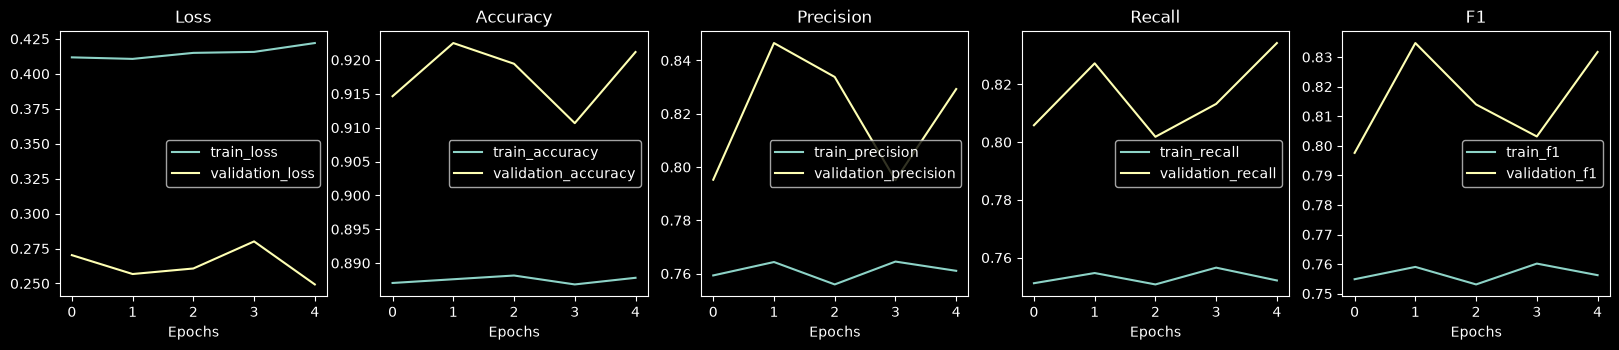

In [54]:
plot_loss_curves(results)

In [56]:
import mlxtend
print(mlxtend.__version__)

0.25.0


In [57]:
# Import tqdm.auto
from tqdm.auto import tqdm
# 1. Make predictions with the trained model
y_preds= []
model_1.eval()
with torch.inference_mode():
    for X, y in tqdm(val_dataloader, desc= "Making predictions..."):
        # Send the data and targets to the target device
        X, y = X.to(device), y.to(device)
        # Do the forward Pass
        y_logit = model_1(X)
        # Turn predictions from logits -> prediction probabilities -> prediction labels
        y_pred = torch.softmax(y_logit.squeeze(), dim=0).argmax(dim=1)
        # Put predictions on CPU for evaluation
        y_preds.append(y_pred.cpu())
    # Concatenate the list of predictions into a tensor
    # print(y_preds)
    y_pred_tensor = torch.cat(y_preds)

Making predictions...:   0%|          | 0/307 [00:00<?, ?it/s]

In [59]:
val_data = datasets.ImageFolder(val_dir,
                                auto_transforms)
val_data

Dataset ImageFolder
    Number of datapoints: 9806
    Root location: data\val
    StandardTransform
Transform: ImageClassification(
               crop_size=[384]
               resize_size=[384]
               mean=[0.485, 0.456, 0.406]
               std=[0.229, 0.224, 0.225]
               interpolation=InterpolationMode.BILINEAR
           )

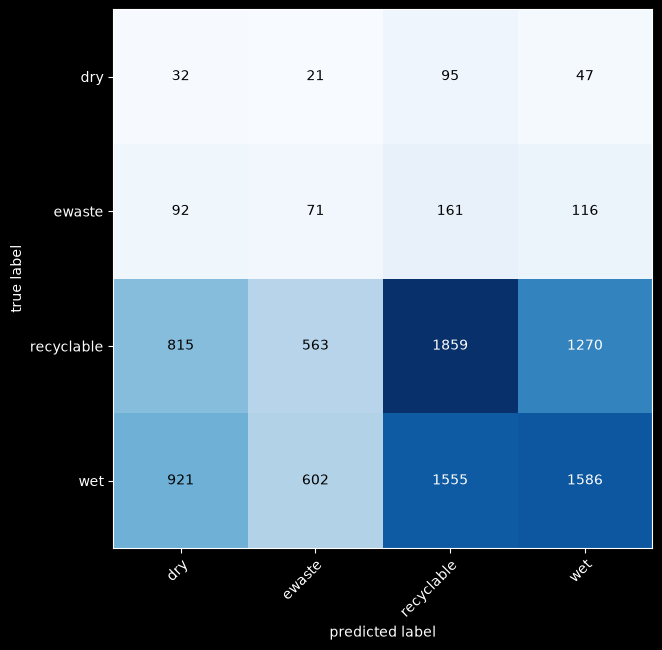

In [61]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix
import torch

# 1. Convert predictions to a single tensor (if y_pred_tensor is a list of tensors)
if isinstance(y_pred_tensor, list):
    y_pred_tensor = torch.cat(y_pred_tensor)

# 2. Convert targets to tensor
targets_tensor = torch.tensor(val_data.targets)

# 3. Set up a confusion instance and compare predictions to targets
confmat = ConfusionMatrix(task='multiclass', num_classes=len(class_names))
confmat_tensor = confmat(preds=y_pred_tensor, target=targets_tensor)

# 4. Plot the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 7)
)

As expected, the class imbalance is clear. The bottom half of the matrix is blue, which means the model predicts `recyclable` and `wet` more often as their samples are more in number. This is not our model's fault, rather the root issue lies in the data. This is not good. To fix this, we have to change our dataset first.

### Solving the problem
To solve this problem, we have to make a few changes to the dataloaders like:
* Distribute all the classes evenly throughout the dataloaders.
* Make sure that the classes are balanced.